In [1]:
import os
import pandas as pd
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
!pip install albumentations
import albumentations as A
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D,Flatten,Dense
from tensorflow.keras.optimizers import Adam

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

#connecting to the drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!apt-get install p7zip-full

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.


In [5]:
!7z x "/content/drive/MyDrive/data.7z" -o/content/myData


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/drive/MyDrive/                                 1 file, 378401587 bytes (361 MiB)

Extracting archive: /content/drive/MyDrive/data.7z
--
Path = /content/drive/MyDrive/data.7z
Type = 7z
Physical Size = 378401587
Headers Size = 269559
Method = LZMA2:25
Solid = +
Blocks = 1

  0%      1% 107 - data/IMG/center_2026_04_22_09_21_38_423.jpg                                                        1% 108 - data/IMG/center_2026_04_22_09_21_38_523.jpg                                                      

**UTILS**

In [6]:
def importDatainfo(path):
  columns = ['Center','Left','Right','Steering','Throttle','Brake','Speed']
  data = pd.read_csv(os.path.join(path,'driving_log.csv'), names = columns)
  data['Center'] = data['Center'].apply(getname)
  return data

def getname(filepath):
  return filepath.split('\\')[-1]

def balanceData(data,display=True):
  nBins = 31
  samplePerBin = 500
  hist, bins = np.histogram(data['Steering'],nBins,range=(-1,1 ))
  if display:
    center = (bins[:-1] + bins[1:])/2
    #print(center)
    plt.bar(center,hist,width= 0.06)
    plt.plot((-1,1),(samplePerBin,samplePerBin))
    plt.show()

  removeIndexList = []
  for j in range(nBins):
    binDataList = []
    for i in range(len(data["Steering"])):
      if data['Steering'][i] >= bins[j] and data['Steering'][i] <= bins[j+1]:
        binDataList.append(i)
    binDataList = shuffle(binDataList)
    binDataList = binDataList[samplePerBin:]
    removeIndexList.extend(binDataList)
  print("Removed Images: ",len(removeIndexList))
  data.drop(data.index[removeIndexList],inplace= True)
  print("remaining Images: ",len(data))

  if display:
    hist, _ = np.histogram(data['Steering'],nBins,range=(-1,1 ))
    plt.bar(center,hist,width= 0.06)
    plt.plot((-1,1),(samplePerBin,samplePerBin))
    plt.show()
  return data

def loadData(path,data):
  imagesPath = []
  steering = []

  for i in range(len(data)):
    indexedData = data.iloc[i]
    #print(indexedData)
    imagesPath.append(os.path.join(path,'IMG',indexedData[0]))
    steering.append(float(indexedData[3]))

  imagesPath = np.asarray(imagesPath)
  steering = np.asarray(steering)
  return imagesPath, steering


def augmentImage(imgPath, steering):
    img = mpimg.imread(imgPath)

    # Pan (shift)
    if np.random.rand() < 0.5:
        transform = A.Affine(translate_percent={'x':(-0.1,0.1),'y':(-0.1,0.1)})
        img = transform(image=img)['image']

    # Zoom
    if np.random.rand() < 0.5:
        transform = A.Affine(scale=(1,1.2))
        img = transform(image=img)['image']

    # Brightness
    if np.random.rand() < 0.5:
        transform = A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0)
        img = transform(image=img)['image']

    # Flip
    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)
        steering = -steering

    return img, steering


def preProcessing(img):
  img = img[60:135,:,:]
  img = cv2.cvtColor(img,cv2.COLOR_RGB2YUV)
  img = cv2.GaussianBlur(img, (3,3), 0)
  img = cv2.resize(img,(200,66))
  img = img/255
  return img


def batchGen(imagesPath,steeringList,batchSize,trainFlag):
  while True:
    imgBatch = []
    steeringBatch = []

    for i in range(batchSize):
      index = random.randint(0,len(imagesPath)-1)
      if trainFlag:
        img, steering = augmentImage(imagesPath[index],steeringList[index])
      else:
        img = mpimg.imread(imagesPath[index])
        steering =steeringList[index]
      img = preProcessing(img)
      imgBatch.append(img)
      steeringBatch.append(steering)

    yield(np.asarray(imgBatch),np.asarray(steeringBatch))


def creatModel():
  model = Sequential()
  model.add(Convolution2D(24, kernel_size=(5,5), strides=(2,2),input_shape = (66,200,3),activation='elu'))
  model.add(Convolution2D(36, kernel_size=(5,5), strides=(2,2),activation='elu'))
  model.add(Convolution2D(48, kernel_size=(5,5), strides=(2,2),activation='elu'))
  model.add(Convolution2D(64, kernel_size=(3,3), activation='elu'))
  model.add(Convolution2D(64, kernel_size=(3,3), activation='elu'))

  model.add(Flatten())
  model.add(Dense(100,activation ='elu'))
  model.add(Dense(50,activation ='elu'))
  model.add(Dense(10,activation ='elu'))
  model.add(Dense(1))

  model.compile(Adam(learning_rate=0.0001),loss = 'mse')
  return model

**TRAINING SIMULATION**

In [7]:
####step 1
path = 'myData/data'
data = importDatainfo(path)


####step 2
data = balanceData(data,False)

###step 3
imagesPath , steering = loadData(path,data)
#print(imagesPath[0], steering[0])

###step 4
xTrain, xval ,yTrain ,yval=train_test_split(imagesPath,steering ,test_size = 0.2 ,random_state = 5)
print('xtrain: ',len(xTrain))
print('xval: ',len(xval))

###step 5  augmentation

### step 7
model = creatModel()
model.summary()



Removed Images:  6178
remaining Images:  2550
xtrain:  2040
xval:  510


/tmp/ipykernel_7563/2749341628.py:48: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  imagesPath.append(os.path.join(path,'IMG',indexedData[0]))
/tmp/ipykernel_7563/2749341628.py:49: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexedData[3]))
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
### train
history = model.fit(batchGen(xTrain,yTrain,100,1),steps_per_epoch=300,epochs= 10
          ,validation_data=batchGen(xval,yval,100,0),validation_steps=200)



Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 102s 316ms/step - loss: 0.0463 - val_loss: 0.0277
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 143s 477ms/step - loss: 0.0356 - val_loss: 0.0262
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 97s 323ms/step - loss: 0.0323 - val_loss: 0.0243
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 140s 470ms/step - loss: 0.0296 - val_loss: 0.0230
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 96s 321ms/step - loss: 0.0283 - val_loss: 0.0235
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 91s 304ms/step - loss: 0.0271 - val_loss: 0.0247
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 91s 306ms/step - loss: 0.0269 - val_loss: 0.0236
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 91s 304ms/step - loss: 0.0260 - val_loss: 0.0233
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 92s 307ms/step - loss: 0.0252 - val_loss: 0.0244
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 135s 452ms/step - loss: 0.0248 - val_loss: 0.0228


Model saved


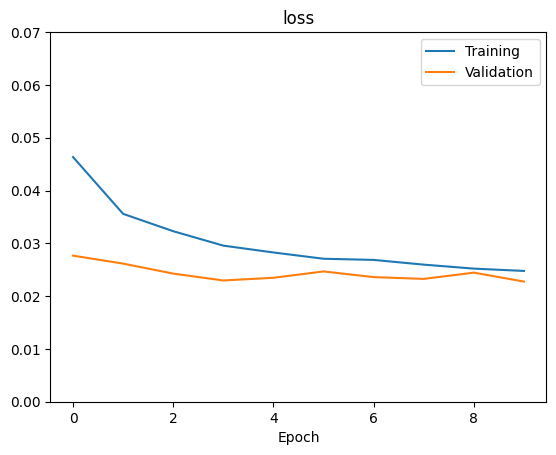

In [9]:
###
model.save('model.h5')
print("Model saved")

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Training','Validation'])
plt.ylim([0.0,0.07])
plt.title('loss')
plt.xlabel('Epoch')
plt.show()

In [10]:
from google.colab import files
files.download("model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>